# Forecast

เป้าหมายคือ ใช้ข้อมูลเสาปีที่มี (2024) ทำนายปีถัดไป (2025) แล้วเทียบกับข้อมูลเสาจริงเมื่อได้ไฟล์มา

## CELL 1 - ตั้งไซต์

In [1]:
import os
os.environ["UWIN_SITE"] = "013054"

## CELL 2 - import + ค่าที่ต้องแก้ก่อนรัน

- ACTUAL_FILE : ชื่อไฟล์เสาปีที่ทำนาย ถ้ายังไม่มีให้เป็น None จะข้ามการเทียบผล
- START, END : ช่วงเวลาที่ทำนาย
- REUSE_MODEL : stamp Model Stage 4 ใช้เติมช่องว่าง WS160 ของ Raw Data ตอนเทียบผล

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from uwinControl import config, data_io, energy, features, forecast, models, qc, reference

def show(title, **kv):
    print(f"[{title}] " + " | ".join(f"{key} = {value}" for key, value in kv.items()))

SITE = config.get_site()
TARGET = f"WS{SITE['mast_height_m']}"
HUB_HEIGHT = SITE['hub_height_m']

TRAIN_FILE = SITE['raw_filename'] # Raw Data 2024
ACTUAL_FILE = "wind_raws_2025.csv" # ใส่ชื่อไฟล์ของปี 2025
START, END = "2025-01-01", "2029-12-31 23:50"
HEIGHTS = (100, 120, 140, 150, 160, 170, 180) # ความสูงที่จะคิดพลังงาน ต้องมี hub height อยู่ด้วย
REUSE_MODEL = None # stamp โมเดล

assert not config.validate_site()

I0000 00:00:1789701481.438117   28289 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789701482.622211   28289 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789701486.301827   28289 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## CELL 3 - Load Data + QC + ERA5

ใช้ข้อมูลลม WS160 ที่ทำการวัดจริง ยกไปเป็น hub height ด้วย Power Law

In [3]:
raw_data = data_io.load_raw_data(TRAIN_FILE)
clean_data = qc.run_qc(raw_data)
print("")
era5_data = reference.load_era5()

DATA_VERSION = data_io.save_version(raw_data, note = "forecast train")
RUN_ID = data_io.start_run(note = f"FORECAST {START[:4]}", data_version = DATA_VERSION, era5_info = reference.era5_info(era5_data))

# ข้อมูลลมวัดจริงจากยอดเสา ยกไปเป็น hub height ด้วย Power Law
_, ALPHA = features.compute_alpha(features.build_features(clean_data))
HUB_FACTOR = (HUB_HEIGHT / SITE['mast_height_m']) ** ALPHA
wind = clean_data[TARGET] * HUB_FACTOR
AIR_DENSITY = energy.air_density(clean_data['Temp'].median(), clean_data['Pres'].median())

show(
    'TRAIN', 
    ช่วงเวลา = f"{wind.first_valid_index():%d %b %Y} - {wind.last_valid_index():%d %b %Y}",
    coverage = f"{wind.notna().mean()*100:.1f}%", 
    alpha = f"{ALPHA:.4f}", 
    hub_factor = f"{HUB_FACTOR:.4f}", 
    air_density = f"{AIR_DENSITY:.4f}"
    )

display(pd.DataFrame({
    "windspeed_mean": wind.resample("MS").mean(), 
    "coverage_pct": wind.notna().resample("MS").mean() * 100
    }).round(2).T)

ช่วงเวลา: 2024-01-01 00:00:00 ถึงช่วง 2024-12-31 23:50:00 (GMT+7)
แถวที่มี 50,646 จากแถวที่ควรมี 52,704 (coverage 96.10%)
แถวที่หายไป 2,058

QC SD: ตัดค่านอกช่วง [0.0, 5.0] ตัดออก 5 แถว (0.01%)
QC Temp: ตัดค่านอกช่วง [5.0, 50.0] ตัดออก 4,847 แถว (9.20%)
QC Pres: ตัดค่านอกช่วง [950.0, 1050.0] ตัดออก 4,846 แถว (9.19%)

พิกัดที่ใช้ในการกริด: 16.000, 104.250 (พิกัดห่างจากไซต์ 2.9 กม.)
ช่วงเวลา: 2006-01-01 07:00:00 ถึงช่วง 2026-08-18 12:00:00 (เวลา Asia/Bangkok)
จำนวนแถว: 180,822
ลมเฉลี่ยที่ 100 ม.: 4.99 m/s

Run file: /home/jovyan/project/data/outputs/013054_20260918_031912
[TRAIN] ช่วงเวลา = 01 Jan 2024 - 31 Dec 2024 | coverage = 88.4% | alpha = 0.2241 | hub_factor = 0.9856 | air_density = 1.1521


timestamp,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01
windspeed_mean,5.15,5.10,4.35,3.85,4.04,5.97,5.46,5.01,6.98,4.26,3.66,5.32
coverage_pct,96.59,96.55,100.00,100.00,99.89,98.08,99.98,99.98,99.86,99.93,26.39,43.64


## CELL 4 - fit + gate การแจกแจงข้อมูล

ตรวจค่าลมที่จำลอง ว่าเหมือนข้อมูลจริงไหม
- sd = ความแกว่งของข้อมูลที่จำลองมา (0.8 - 1.2)
- KS = ระยะห่างของการกระจายตัวข้อมูล (< 0.10) 
- Weibull k = การกระจายตัวของข้อมูลลม (ไม่เกิน 0.3)

In [4]:
state = forecast.fit(wind, era5_data)

# gate: ลมที่จำลองต้องมีการแจกแจงเหมือนของจริง ถ้าไม่ผ่านห้ามใช้ต่อ
simulate = [forecast.simulate(state, wind.index.min(), wind.index.max(), seed = s) for s in range(10)]
real_data = wind.dropna()
sd_ratio = np.mean([s.std() for s in simulate]) / real_data.std()
ks_statistic = np.mean([stats.ks_2samp(s.dropna(), real_data).statistic for s in simulate])
k_real_data = energy.fit_weibull(real_data)[0]
k_simulate = energy.fit_weibull(simulate[0])[0]

show(
    'FIT', 
    level = config.FORECAST['level_source'], 
    interannual_variability = f"{state['interannual_variability']*100:.2f}%",
    sd_ratio = f"{sd_ratio:.3f}", 
    KS = f"{ks_statistic:.3f}", 
    k_real_data = f"{k_real_data:.3f}", 
    k_simulate = f"{k_simulate:.3f}")
assert 0.8 <= sd_ratio <= 1.2 and ks_statistic < 0.10 and abs(k_real_data - k_simulate) <= 0.3, "การแจกแจงไม่ผ่าน"

[FIT] level = site | interannual_variability = 4.01% | sd_ratio = 0.960 | KS = 0.050 | k_real_data = 2.228 | k_simulate = 2.179


## CELL 5 - Predict

- forecast_10min.csv : Expectation + ex 1 line
- forecast_D/MS/YS.csv : ค่าสถิติลมและพลังงานแบบ P10/P50/P90 จาก ensemble

ค่ารายชั่วโมงถูกต้องเชิงสถิติ ไม่ถูกต้องราย timestamp

In [5]:
point = forecast.expected(state, START, END) # ค่าคาดหวังราย 10 นาที (point forecast)
sample = forecast.simulate(state, START, END, seed = 0) # ตัวอย่าง 1 เส้นที่แกว่งเหมือนจริง
data_io.save_output(pd.DataFrame({"windspeed_expected": point, "windspeed_sample": sample}), "forecast_10min")

outputs = {}
for freq in ("D", "MS", "YS"):
    outputs[freq] = forecast.ensemble_stats(state, START, END, freq, air_density = AIR_DENSITY)
    data_io.save_output(outputs[freq], f"forecast_{freq}")

year = outputs["YS"].iloc[0]
show(
    f'FORECAST {START[:4]} @ {HUB_HEIGHT} m',
    ws_mean = f"{year['windspeed_mean_p50']:.2f} ({year['windspeed_mean_p10']:.2f}-{year['windspeed_mean_p90']:.2f}) m/s",
    ws_max = f"{year['windspeed_max_p50']:.1f} m/s",
    energy = f"{year['energy_mwh_p50']/1000:.1f} ({year['energy_mwh_p10']/1000:.1f}-{year['energy_mwh_p90']/1000:.1f}) GWh",
    CF = f"{year['capacity_factor_pct_p50']:.1f}%")
display(outputs["MS"][["windspeed_mean_p10", "windspeed_mean_p50", "windspeed_mean_p90", "windspeed_max_p50", "windspeed_sd_p50", "energy_mwh_p50"]].round(2))

Save: 013054_20260918_031912/forecast_10min.csv
Save: 013054_20260918_031912/forecast_D.csv
Save: 013054_20260918_031912/forecast_MS.csv
Save: 013054_20260918_031912/forecast_YS.csv
[FORECAST 2025 @ 150 m] ws_mean = 4.89 (4.58-5.23) m/s | ws_max = 19.6 m/s | energy = 34.3 (27.6-42.1) GWh | CF = 8.7%


,windspeed_mean_p10,windspeed_mean_p50,windspeed_mean_p90,windspeed_max_p50,windspeed_sd_p50,energy_mwh_p50
2025-01-01,4.34,5.02,5.89,12.07,2.16,2897.31
2025-02-01,4.12,4.94,5.75,11.45,2.04,2421.89
2025-03-01,3.94,4.30,4.73,9.58,1.71,1529.73
2025-04-01,3.61,3.85,4.11,9.27,1.55,978.14
2025-05-01,3.63,4.00,4.36,11.83,1.87,1415.11
2025-06-01,5.13,5.83,6.53,16.94,2.47,4425.27
2025-07-01,4.77,5.37,5.99,19.33,2.17,3372.36
2025-08-01,4.80,5.37,6.03,14.09,2.36,3631.90
2025-09-01,5.40,6.64,7.89,16.15,2.77,6573.67
2025-10-01,3.51,4.22,5.00,12.79,2.48,2347.67


## CELL 5B - File Forecast รูปแบบ Raw Data

- forecast_raws_<ปี>_seed0.csv คอลัมน์และ channel เหมือนไฟล์ Raw Data ทุกอย่าง (15 channel, avg/gust/gust_dir/max/min/sd)
- เป็น 1 ปีที่เป็นไปได้ (seed 0 เส้นเดียวกับ `windspeed_sample`) ไม่ใช่ P50 -> ค่า P10/P50/P90 ดูจาก forecast_MS/YS.csv
- round-trip: โหลดไฟล์กลับผ่าน load_raw_data -> run_qc ต้องได้ WS160 ตรงกับ ws_sample


In [6]:
raw_forecast = forecast.to_raw(state, TRAIN_FILE, START, END, seed = 0)
RAW_FORECAST_FILE = data_io.run_dir() / f"forecast_raws_{START[:4]}_seed.csv" # ชื่อไฟล์
raw_forecast.to_csv(RAW_FORECAST_FILE, index = False)

show(
    'RAW FORECAST',
    ชื่อไฟล์ = RAW_FORECAST_FILE.name,
    จำนวนแถวข้อมูล = f"{len(raw_forecast):,}",
    channel_sensor = raw_forecast['channel'].nunique(),
    ช่วงเวลา = f"{raw_forecast['timestamp'].iloc[-1][:16]} - {raw_forecast['timestamp'].iloc[0][:16]}",
    )
display(raw_forecast.head(15))

# round-trip: ไฟล์พยากรณ์ต้องเข้าท่อเดิมได้ และ WS160 หลัง QC ต้องตรงกับ ws_sample
check_data = qc.run_qc(data_io.load_raw_data(str(RAW_FORECAST_FILE)))
back = check_data[TARGET] * HUB_FACTOR
month_diff = (back.resample("MS").mean() / sample.resample("MS").mean() - 1) * 100
show(
    'ROUND TRIP',
    ws_raw = f"{back.mean():.3f}",
    ws_sample = f"{sample.mean():.3f}",
    ต่างรายเดือนสูงสุด = f"{month_diff.abs().max():.2f}%",
    )
assert month_diff.abs().max() < 2, "File Raw Data Forecast ไม่ตรงกับ ws_sample"

[RAW FORECAST] ชื่อไฟล์ = forecast_raws_2025_seed.csv | จํานวนแถวข้อมูล = 3,936,180 | channel_sensor = 15 | ช่วงเวลา = 2025-01-01 00:00 - 2029-12-31 23:50


,site_code,sensor_id,timestamp,channel,height,direction,unit,avg,gust,gust_dir,max,min,sd
0,013054,107,2029-12-31 23:50:00.000 +0700,1,160.0,N,m/s,7.115155,8.204911,NaN,8.413024,5.890441,0.440821
1,013054,108,2029-12-31 23:50:00.000 +0700,2,160.0,S,m/s,7.169065,8.224882,NaN,8.433267,5.907389,0.446449
2,013054,109,2029-12-31 23:50:00.000 +0700,3,140.0,N,m/s,6.673534,7.587683,NaN,7.796162,5.269144,0.408114
3,013054,110,2029-12-31 23:50:00.000 +0700,4,120.0,N,m/s,6.176672,7.162963,NaN,7.162963,4.642089,0.441153
4,013054,111,2029-12-31 23:50:00.000 +0700,5,100.0,N,m/s,5.666714,6.524291,NaN,6.524291,4.629791,0.454049
5,013054,112,2029-12-31 23:50:00.000 +0700,6,80.0,N,m/s,5.110183,6.322421,NaN,6.530558,4.007690,0.470515
6,013054,113,2029-12-31 23:50:00.000 +0700,7,60.0,N,m/s,4.456239,5.684273,NaN,5.892842,3.364725,0.451268
7,013054,119,2029-12-31 23:50:00.000 +0700,13,152.0,N,Deg,45.810000,NaN,44.21,NaN,NaN,2.530000
8,013054,120,2029-12-31 23:50:00.000 +0700,14,152.0,S,Deg,39.610000,NaN,35.22,NaN,NaN,2.520000
9,013054,121,2029-12-31 23:50:00.000 +0700,15,132.0,N,Deg,41.320000,NaN,40.03,NaN,NaN,3.100000


ช่วงเวลา: 2025-01-01 00:00:00 ถึงช่วง 2029-12-31 23:50:00 (GMT+7)
แถวที่มี 262,412 จากแถวที่ควรมี 262,944 (coverage 99.80%)
แถวที่หายไป 532

QC SD: ตัดค่านอกช่วง [0.0, 5.0] ตัดออก 20 แถว (0.01%)
QC Temp: ตัดค่านอกช่วง [5.0, 50.0] ตัดออก 26,250 แถว (9.98%)
QC Pres: ตัดค่านอกช่วง [950.0, 1050.0] ตัดออก 26,250 แถว (9.98%)
[ROUND TRIP] ws_raw = 4.741 | ws_sample = 4.741 | ต่างรายเดือนสูงสุด = 0.18%


## CELL 6 - เทียบกับ Raw Data

1. คะแนนทุกความละเอียด (R2 ราย 10 นาทีจะใกล้ 0 เป็นเรื่องปกติ)
2. skill เทียบการก๊อปปีก่อน - ติดลบแปลว่าแพ้
3. รายเดือนตกในช่วง P10-P90 ไหม
4. การแจกแจงทั้งปี

In [7]:
VERIFIED = ACTUAL_FILE is not None
if VERIFIED:
    clean_actual = qc.run_qc(data_io.load_raw_data(ACTUAL_FILE)) # QC ข้อมูลชุดเดียวกับตอนเทรน
    actual = clean_actual[TARGET]
    if REUSE_MODEL: # เติมช่องว่าง WS160 ด้วยโมเดล Stage 4 ใช้กับค่าเฉลี่ย/พลังงานได้ ไม่ใช้กับการแจกแจง
        feat = features.build_features(clean_actual)
        x = feat[features.feature_columns()].dropna()
        model, card = models.load_model(REUSE_MODEL, features.feature_columns())
        mode = 'alpha' if card['model_name'].endswith('_alpha') else 'direct'
        base_sensor = SITE['base_sensor']
        filled = pd.Series(models.predict_hub_wind(model, x, mode, base_sensor, SITE['sensor_heights'][base_sensor], SITE['mast_height_m']), index = x.index)

        show(
            'GAP FILL', 
            Before = f"{actual.notna().mean()*100:.1f}%", 
            After = f"{actual.fillna(filled).notna().mean()*100:.1f}%")

        measured_only = actual.loc[START:END].dropna() * HUB_FACTOR # เก็บค่าวัดล้วนไว้เทียบการแจกแจง
        actual = actual.fillna(filled)
    actual = actual.loc[START:END] * HUB_FACTOR
    if not REUSE_MODEL:
        measured_only = actual.dropna()

    # 1. เทียบค่าคาดหวังกับค่าจริงทุกความละเอียด
    FREQS = ("10min", "1h", "D", "MS")   # รายปีมีจุดเดียว คิด R2 ไม่ได้ ดูจากแถว ANNUAL แทน
    scores = forecast.score_by_freq(actual, point, freqs = FREQS)

    # 2. skill เทียบกับการก๊อปปีก่อน (persistence) ติดลบ = แพ้ ห้ามใช้โมเดล
    persistence = wind.shift(freq = pd.DateOffset(years = 1))
    persistence = persistence[~persistence.index.duplicated()].reindex(point.index)
    base_scores = forecast.score_by_freq(actual, persistence, freqs = FREQS)
    scores["skill_vs_persistence"] = 1 - scores["RMSE"]**2 / base_scores["RMSE"]**2
    display(scores.round(3))

    # 3. รายเดือน: ค่าจริงตกในช่วง P10-P90 ไหม
    real_month = forecast.wind_stats(actual, "MS").join(forecast.energy_stats(actual, "MS", AIR_DENSITY))
    forecast_monthly = outputs["MS"]
    monthly = pd.DataFrame({
        "ws_real": real_month["windspeed_mean"], 
        "ws_p10": forecast_monthly["windspeed_mean_p10"], 
        "ws_p50": forecast_monthly["windspeed_mean_p50"], 
        "ws_p90": forecast_monthly["windspeed_mean_p90"],
        "ws_err_pct": (forecast_monthly["windspeed_mean_p50"] / real_month["windspeed_mean"] - 1) * 100,
        "mwh_real": real_month["energy_mwh"], 
        "mwh_p50": forecast_monthly["energy_mwh_p50"],
        "mwh_err_pct": (forecast_monthly["energy_mwh_p50"] / real_month["energy_mwh"] - 1) * 100,
        "coverage_pct": real_month["coverage_pct"],
    })
    monthly = monthly.dropna(subset = ["ws_real"]) # ให้เทียบเฉพาะเดือนที่มีข้อมูล
    forecast_monthly = forecast_monthly.loc[monthly.index] # ตัดให้เหลือแค่เดือนเดียวกับ Raw Data
    monthly["in_band"] = monthly["ws_real"].between(monthly["ws_p10"], monthly["ws_p90"])
    display(monthly.round(2))

    real_year = forecast.wind_stats(actual, "YS").join(forecast.energy_stats(actual, "YS", AIR_DENSITY)).iloc[0]
    year = outputs["YS"].loc[real_year.name] # ใช้ปีเดียวกับ Raw Data
    show('ANNUAL', 
         ws_real = f"{real_year['windspeed_mean']:.2f}", 
         ws_forecast = f"{year['windspeed_mean_p50']:.2f}",
         ws_err = f"{(year['windspeed_mean_p50'] / real_year['windspeed_mean'] - 1) * 100:+.1f}%",
         mwh_real = f"{real_year['energy_mwh']:,.0f}", 
         mwh_forecast = f"{year['energy_mwh_p50']:,.0f}",
         mwh_err = f"{(year['energy_mwh_p50'] / real_year['energy_mwh'] - 1) * 100:+.1f}%",
         in_P10_P90 = real_year['energy_mwh'] >= year['energy_mwh_p10'] and real_year['energy_mwh'] <= year['energy_mwh_p90'])

    # 4. การแจกแจงทั้งปี ใช้ค่าวัดล้วน ไม่ใช้ค่าที่โมเดลเติม
    show(
        'DISTRIBUTION', 
        sd_ratio = f"{sample.std()/measured_only.std():.3f}",
        KS = f"{stats.ks_2samp(sample.dropna(), measured_only).statistic:.3f}",
        k_real = f"{energy.fit_weibull(measured_only)[0]:.3f}", 
        k_forecast = f"{energy.fit_weibull(sample)[0]:.3f}",
        in_band = f"{monthly['in_band'].mean()*100:.0f}%")
    data_io.save_output(scores, "verify_scores")
    data_io.save_output(monthly, "verify_monthly")
else:
    show('VERIFY', สถานะ = "ยังไม่มีข้อมูลเสาจริงของช่วงที่ทำนาย ข้ามการเทียบผล")

ช่วงเวลา: 2025-01-01 00:00:00 ถึงช่วง 2025-12-31 23:50:00 (GMT+7)
แถวที่มี 52,560 จากแถวที่ควรมี 52,560 (coverage 100.00%)
แถวที่หายไป 0

QC SD: ตัดค่านอกช่วง [0.0, 5.0] ตัดออก 1 แถว (0.00%)
QC Temp: ตัดค่านอกช่วง [5.0, 50.0] ตัดออก 2 แถว (0.00%)
QC Pres: ตัดค่านอกช่วง [950.0, 1050.0] ตัดออก 2 แถว (0.00%)


,MAE,RMSE,MAPE,R2,Hit10_pct,bias,n,skill_vs_persistence
model,,,,,,,,
10min,1.927,2.409,26.662,0.067,19.385,-0.363,52482,0.410
1h,1.874,2.324,26.467,0.071,19.265,-0.366,8740,0.407
D,1.519,1.870,25.619,0.085,19.091,-0.361,365,0.357
MS,0.600,0.747,10.686,0.409,50.000,-0.366,12,0.354


,ws_real,ws_p10,ws_p50,ws_p90,ws_err_pct,mwh_real,mwh_p50,mwh_err_pct,coverage_pct,in_band
2025-01-01,5.46,4.34,5.02,5.89,-7.98,3535.94,2897.31,-18.06,100.00,True
2025-02-01,5.34,4.12,4.94,5.75,-7.48,3483.78,2421.89,-30.48,100.00,True
2025-03-01,4.58,3.94,4.30,4.73,-6.04,2121.05,1529.73,-27.88,99.64,True
2025-04-01,3.91,3.61,3.85,4.11,-1.63,1435.96,978.14,-31.88,99.98,True
2025-05-01,4.80,3.63,4.00,4.36,-16.84,2874.26,1415.11,-50.77,99.80,False
2025-06-01,6.04,5.13,5.83,6.53,-3.47,4754.18,4425.27,-6.92,99.93,True
2025-07-01,7.47,4.77,5.37,5.99,-28.01,7646.82,3372.36,-55.90,100.00,False
2025-08-01,5.70,4.80,5.37,6.03,-5.80,4642.72,3631.90,-21.77,99.69,True
2025-09-01,6.22,5.40,6.64,7.89,6.74,5151.22,6573.67,27.61,99.91,True
2025-10-01,4.00,3.51,4.22,5.00,5.40,1403.87,2347.67,67.23,99.98,True


[ANNUAL] ws_real = 5.30 | ws_forecast = 4.89 | ws_err = -7.8% | mwh_real = 43,438 | mwh_forecast = 34,305 | mwh_err = -21.0% | in_P10_P90 = False
[DISTRIBUTION] sd_ratio = 0.919 | KS = 0.104 | k_real = 2.226 | k_forecast = 2.188 | in_band = 67%
Save: 013054_20260918_031912/verify_scores.csv
Save: 013054_20260918_031912/verify_monthly.csv


## CELL 6B - ตารางความแม่นยำเทียบกับ Raw Data

- ความแม่นยำ % = 100 - MAPE: ค่าลมคิดเฉพาะช่วงที่เป็นค่าลมจริง > 3 m/s
- bias % = ทายค่าเฉลี่ยว่าได้เท่าไหร่ ถ้า สูงเป็น (+) หรือต่ำเป็น (-) บอกเฉลี่ยว่าสูงหรือต่ำกว่าค่าจริงกี่เปอร์เซ็น
- skill = 1 - MSE Model / MSE ของการก๊อปข้อมูลปี 2024 ถ้าค่ามากกว่า 0 = ดีและต้องดูคู่กับค่าความแม่นยำ
- P10–P90 % = ค่าจริงที่ตกในช่วงที่พยากรณ์ว่าตกไปกี่เปอร์เซ็น (ค่าควรใกล้ 80)
- ค่าลมราย 10 นาที / ชั่วโมง / วัน แสดงไว้เป็นค่าอ้างอิง

In [8]:
if VERIFIED:
    unit_ws = "m/s"
    names = {"10min": "ค่าลม 10 นาที", "1h": "ค่าลมรายชั่วโมง", "D": "ค่าลมรายวัน", "MS": "ค่าลมรายเดือน"}
    accuracy = scores.rename(index = names)[["n", "MAE", "RMSE", "MAPE", "R2", "bias", "skill_vs_persistence"]].copy()
    accuracy["หน่วย"] = unit_ws
    accuracy["bias"] = accuracy["bias"] / actual.mean() * 100
    accuracy.loc["ค่าลมรายเดือน", "P10-P90 %"] = monthly["in_band"].mean() * 100

    # พลังงานรายเดือน
    energy_score = models.evaluate(monthly["mwh_real"], monthly["mwh_p50"], "energy")
    energy_persistence = forecast.energy_stats(persistence, "MS", AIR_DENSITY)["energy_mwh"]
    accuracy.loc["พลังงานรายเดือน"] = pd.Series({
        "หน่วย": "MWh",
        "n": len(monthly),
        "MAE": energy_score["MAE"],
        "RMSE": energy_score["RMSE"],
        "MAPE": energy_score["MAPE"],
        "R2": energy_score["R2"],
        "bias": (monthly["mwh_p50"] - monthly["mwh_real"]).mean() / monthly["mwh_real"].mean() * 100,
        "skill_vs_persistence": 1 - energy_score["RMSE"]**2 / ((energy_persistence - monthly["mwh_real"])**2).mean(),
        "P10-P90 %": monthly["mwh_real"].between(forecast_monthly["energy_mwh_p10"], forecast_monthly["energy_mwh_p90"]).mean() * 100,
    })

    # รายปี มีจุดเดียว: ไม่มี R2
    persistence_year = forecast.wind_stats(persistence, "YS").join(forecast.energy_stats(persistence, "YS", AIR_DENSITY)).iloc[0]
    for name, col, unit in (("ค่าลมรายปี", "windspeed_mean", unit_ws), ("พลังงานรายปี", "energy_mwh", "MWh")):
        real, pred, copy_2024 = real_year[col], year[f"{col}_p50"], persistence_year[col]
        accuracy.loc[name] = pd.Series({
            "หน่วย": unit,
            "n": 1,
            "MAE": abs(pred - real),
            "RMSE": abs(pred - real),
            "MAPE": abs(pred / real - 1) * 100,
            "R2": np.nan,
            "bias": (pred / real - 1) * 100,
            "skill_vs_persistence": 1 - (pred - real)**2 / (copy_2024 - real)**2,
            "P10-P90 %": 100.0 * (year[f"{col}_p10"] <= real <= year[f"{col}_p90"]),
        })

    accuracy["เปอร์เซ็นความแม่นยำ"] = 100 - accuracy["MAPE"]
    accuracy = accuracy.rename(columns = {"MAPE": "MAPE %", "bias": "bias %", "skill_vs_persistence": "skill"})
    accuracy = accuracy[["หน่วย", "n", "MAE", "RMSE", "MAPE %", "เปอร์เซ็นความแม่นยำ", "bias %", "R2", "skill", "P10-P90 %"]]
    accuracy["n"] = accuracy["n"].astype(int)
    data_io.save_output(accuracy, "verify_accuracy")
    display(accuracy.round(3))

Save: 013054_20260918_031912/verify_accuracy.csv


,หน่วย,n,MAE,RMSE,MAPE %,เปอร์เซ็นความแม่นยำ,bias %,R2,skill,P10-P90 %
model,,,,,,,,,,
ค่าลม 10 นาที,m/s,52482,1.927,2.409,26.662,73.338,-6.852,0.067,0.410,NaN
ค่าลมรายชั่วโมง,m/s,8740,1.874,2.324,26.467,73.533,-6.900,0.071,0.407,NaN
ค่าลมรายวัน,m/s,365,1.519,1.870,25.619,74.381,-6.800,0.085,0.357,NaN
ค่าลมรายเดือน,m/s,12,0.600,0.747,10.686,89.314,-6.911,0.409,0.354,66.667
พลังงานรายเดือน,MWh,12,1298.591,1704.687,35.963,64.037,-22.392,0.075,0.204,50.000
ค่าลมรายปี,m/s,1,0.416,0.416,7.843,92.157,-7.843,NaN,-0.728,0.000
พลังงานรายปี,MWh,1,9132.922,9132.922,21.025,78.975,-21.025,NaN,-0.594,0.000


## CELL 6C - พลังงานที่หลายความสูง

- ลมที่ความสูง h = ลม hub x (h / hub)^alpha
- ค่าความสูงที่เหนือยอดเสา

In [9]:
assert HUB_HEIGHT in HEIGHTS, "HEIGHTS ต้องมี hub height สำหรับคอลัมน์เทียบ hub"
base = forecast.expected(state, START, END)
factors = {height: (height / HUB_HEIGHT) ** ALPHA for height in HEIGHTS}
runs = {height: [] for height in HEIGHTS}
for seed in range(config.FORECAST["ensemble"]):
    windspeed = forecast.simulate(state, START, END, seed, base)
    for height, factor in factors.items():
        runs[height].append(forecast.energy_stats(windspeed * factor, "YS", AIR_DENSITY).iloc[0])

rows = {}
for height, factor in factors.items():
    runs_h = pd.DataFrame(runs[height])
    rows[height] = {
        "ตัวคูณ": factor,
        "ค่าลมที่ P50": year["windspeed_mean_p50"] * factor,
        "MWh P10": runs_h["energy_mwh"].quantile(.1),
        "MWh P50": runs_h["energy_mwh"].quantile(.5),
        "MWh P90": runs_h["energy_mwh"].quantile(.9),
        "CF P50 %": runs_h["capacity_factor_pct"].quantile(.5),
        "ค่านอกช่วงเสา": height > SITE["mast_height_m"],
    }
heights = pd.DataFrame.from_dict(rows, orient = "index")
heights.index.name = "ความสูง m"
heights["เทียบค่า hub height %"] = (heights["MWh P50"] / heights.loc[HUB_HEIGHT, "MWh P50"] - 1) * 100

# แถว hub ต้องตรงกับ ensemble_stats ใน CELL 5 ไม่งั้นแปลว่า seed หรือ base ไม่ตรงกัน
assert abs(heights.loc[HUB_HEIGHT, "MWh P50"] / year["energy_mwh_p50"] - 1) < 1e-9

if VERIFIED:
    heights["MWh raw"] = [forecast.energy_stats(actual * f, "YS", AIR_DENSITY)["energy_mwh"].iloc[0] for f in factors.values()]
    heights["เปอร์เซ็นความแม่นยำ"] = 100 - (heights["MWh P50"] / heights["MWh raw"] - 1).abs() * 100

data_io.save_output(heights, "forecast_heights")
display(heights.round(2))

Save: 013054_20260918_031912/forecast_heights.csv


,ตัวคูณ,ค่าลมที่ P50,MWh P10,MWh P50,MWh P90,CF P50 %,ค่านอกช่วงเสา,เทียบค่า hub height %,MWh raw,เปอร์เซ็นความแม่นยำ
ความสูง m,,,,,,,,,,
100,0.91,4.46,20119.54,25227.99,31194.71,6.40,False,-26.46,32259.02,78.20
120,0.95,4.65,23237.03,29019.92,35733.87,7.36,False,-15.41,36933.59,78.57
140,0.98,4.81,26187.97,32590.52,40043.09,8.27,False,-5.00,41330.99,78.85
150,1.00,4.89,27617.36,34305.29,42056.26,8.70,False,0.00,43438.21,78.97
160,1.01,4.96,29016.02,35983.96,44033.79,9.13,False,4.89,45490.92,79.10
170,1.03,5.03,30385.10,37624.89,45964.93,9.54,True,9.68,47492.97,79.22
180,1.04,5.09,31727.95,39223.26,47834.49,9.95,True,14.34,49447.00,79.32


## CELL 7 - Graph

- ลมเฉลี่ยรายเดือน (ค่าพยากรณ์ P10-P90{สีฟ้า}, ค่าที่พยากรณ์ P50{สีน้ำเงิน}, ค่าจริงที่มี{สีดำ})
- พลังงานรายเดือน (ค่าพยากรณ์ P50{สีฟ้า}, ค่าคาดหวัง P10-P90{เส้นสีดำ}, ค่าจริงที่มี{สีแดง})
- การกระจายตัวของค่าลม

Save: 013054_20260918_031912/forecast_monthly.png


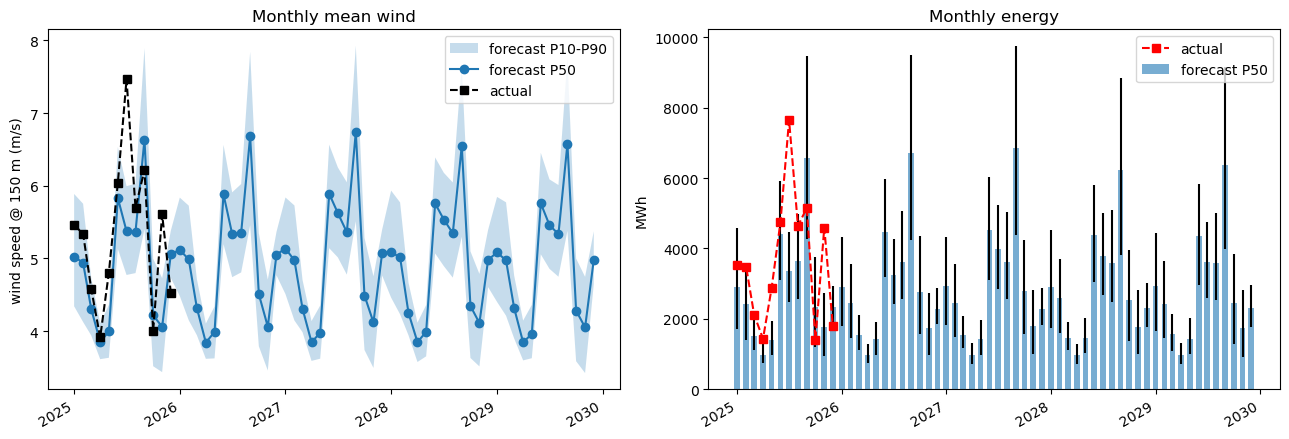

Save: 013054_20260918_031912/verify_scatter.png


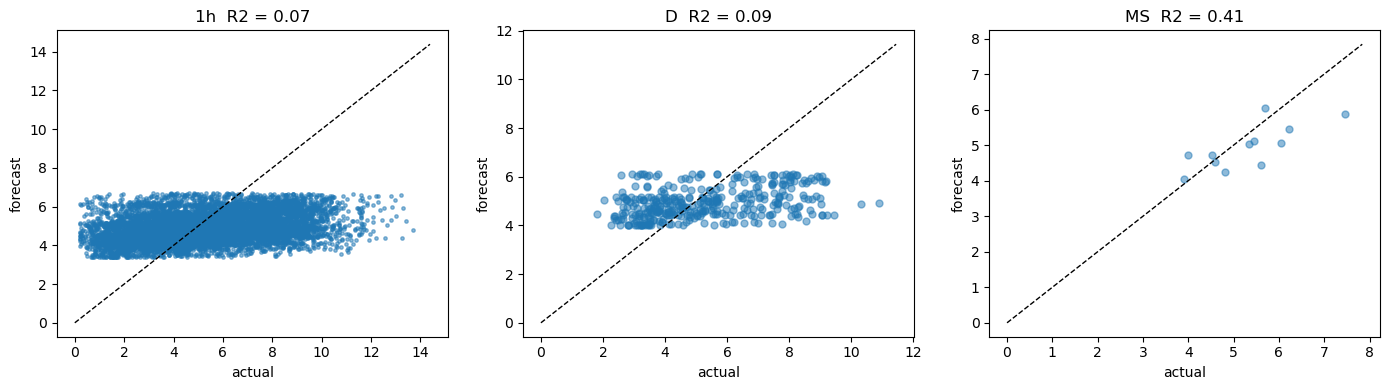

In [10]:
forecast_monthly = outputs["MS"]
fig, ax = plt.subplots(1, 2, figsize = (13, 4.5))

ax[0].fill_between(forecast_monthly.index, forecast_monthly["windspeed_mean_p10"], forecast_monthly["windspeed_mean_p90"], alpha = .25, label = "forecast P10-P90")
ax[0].plot(forecast_monthly.index, forecast_monthly["windspeed_mean_p50"], "o-", label = "forecast P50")
if VERIFIED:
    ax[0].plot(monthly.index, monthly["ws_real"], "s--k", label = "actual")
ax[0].set_ylabel(f"wind speed @ {HUB_HEIGHT} m (m/s)")
ax[0].set_title("Monthly mean wind")
ax[0].legend()

ax[1].bar(forecast_monthly.index, forecast_monthly["energy_mwh_p50"], width = 20, alpha = .6, label = "forecast P50")
ax[1].errorbar(forecast_monthly.index, forecast_monthly["energy_mwh_p50"], yerr = [forecast_monthly["energy_mwh_p50"] - forecast_monthly["energy_mwh_p10"], forecast_monthly["energy_mwh_p90"] - forecast_monthly["energy_mwh_p50"]], fmt = "none", ecolor = "k")
if VERIFIED:
    ax[1].plot(monthly.index, monthly["mwh_real"], "s--r", label = "actual")
ax[1].set_ylabel("MWh")
ax[1].set_title("Monthly energy")
ax[1].legend()

fig.autofmt_xdate()
plt.tight_layout()
data_io.save_image(fig, "forecast_monthly")
plt.show()

if VERIFIED:
    fig, ax = plt.subplots(1, 3, figsize = (14, 4))
    for axis, freq in zip(ax, ("1h", "D", "MS")):
        pair = pd.concat({"real": actual.resample(freq).mean(), "pred": point.resample(freq).mean()}, axis = 1, sort = True).dropna()
        axis.scatter(pair["real"], pair["pred"], s = 6 if freq == "1h" else 25, alpha = .5)
        lim = [0, pair.max().max() * 1.05]
        axis.plot(lim, lim, "k--", lw = 1)
        axis.set_title(f"{freq}  R2 = {scores.loc[freq, 'R2']:.2f}")
        axis.set_xlabel("actual")
        axis.set_ylabel("forecast")
    plt.tight_layout()
    data_io.save_image(fig, "verify_scatter")
    plt.show()

## CELL 8 - บันทึก metadata เตรียมเป็น API

In [11]:
meta = {
    "site": SITE["station_code"], 
    "valid_from": START, 
    "valid_to": END, 
    "height_m": HUB_HEIGHT,
    "method": f"fourier+{config.FORECAST['level_source']}+analog_blocks",
    "raw_forecast_file": RAW_FORECAST_FILE.name,
    "trained_on": state["trained_on"], 
    "data_version": DATA_VERSION,
    "alpha": ALPHA, 
    "air_density": AIR_DENSITY, 
    "interannual_variability": state["interannual_variability"], 
    "ensemble": config.FORECAST["ensemble"],
    "turbine": energy.DEFAULT_TURBINE,
    "verification": ({
        "against": ACTUAL_FILE, 
        "scores": scores.round(4).to_dict("index"),
        "in_band_pct": float(monthly["in_band"].mean() * 100)} if VERIFIED else {"status": "pending"}),
    "limits": {"timestamp_level_valid": False},
}
(data_io.run_dir() / "forecast_meta.json").write_text(json.dumps(meta, indent = 2, ensure_ascii = False, default = str), encoding = "utf-8")
print(f"Result: {data_io.run_dir()}")

Result: /home/jovyan/project/data/outputs/013054_20260918_031912
